# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

According to the Materials and Methods section of the paper, the data represents 17 marketing campaigns.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

RANDOM_STATE=42


In [2]:
bank_data_full= pd.read_csv('data/bank-additional-full.csv', sep = ';')
bank_data = pd.read_csv('data/bank-additional.csv', sep=';')

In [3]:
bank_data_full.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
bank_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [5]:
bank_data_full.shape, bank_data.shape

((41188, 21), (4119, 21))

### Observations 

'bank-additional' is a smaller subset of 4119 observations, compared to 'bank-additional-full' with 41188.

In [6]:
def data_quality_report(df):
  return pd.DataFrame({
    'data_type': df.dtypes,
    'non_null_count': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'na_count': df.isna().sum(),
    'na_percentage': (df.isna().sum() / len(df)) * 100,
    'null_percentage': (df.isnull().sum() / len(df)) * 100,
    'unique_values': df.nunique(),
    'sample_value': df.sample().iloc[0]
  })

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [7]:
data_quality_report(bank_data_full)

,data_type,non_null_count,null_count,na_count,na_percentage,null_percentage,unique_values,sample_value
age,int64,41188,0,0,0.0,0.0,78,33
job,object,41188,0,0,0.0,0.0,12,admin.
marital,object,41188,0,0,0.0,0.0,4,married
education,object,41188,0,0,0.0,0.0,8,high.school
default,object,41188,0,0,0.0,0.0,3,no
housing,object,41188,0,0,0.0,0.0,3,yes
loan,object,41188,0,0,0.0,0.0,3,no
contact,object,41188,0,0,0.0,0.0,2,cellular
month,object,41188,0,0,0.0,0.0,10,jul
day_of_week,object,41188,0,0,0.0,0.0,5,fri


In [9]:
for col in bank_data_full.select_dtypes(include='object').columns.tolist():
  print(f'Unique values for column {col} are {bank_data_full[col].unique()}')

len(bank_data_full[bank_data_full['pdays'] == 999])

Unique values for column job are ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
Unique values for column marital are ['married' 'single' 'divorced' 'unknown']
Unique values for column education are ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
Unique values for column default are ['no' 'unknown' 'yes']
Unique values for column housing are ['no' 'yes' 'unknown']
Unique values for column loan are ['no' 'yes' 'unknown']
Unique values for column contact are ['telephone' 'cellular']
Unique values for column month are ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
Unique values for column day_of_week are ['mon' 'tue' 'wed' 'thu' 'fri']
Unique values for column poutcome are ['nonexistent' 'failure' 'success']
Unique values for column y are ['no' 'yes']


39673

In [8]:
bank_data_full['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [9]:
unknown_rate = (bank_data_full == 'unknown').mean().sort_values(ascending=False)
unknown_rate.head(15)

default           0.208726
education         0.042027
housing           0.024036
loan              0.024036
job               0.008012
marital           0.001942
age               0.000000
poutcome          0.000000
nr.employed       0.000000
euribor3m         0.000000
cons.conf.idx     0.000000
cons.price.idx    0.000000
emp.var.rate      0.000000
duration          0.000000
previous          0.000000
dtype: float64

In [10]:
print('Amount of nonexistenent poutcome values')
bank_data_full[bank_data_full['poutcome'] == 'nonexistent']['poutcome'].count()

Amount of nonexistenent poutcome values


35563

In [11]:
unknown_rate = (bank_data_full == 'unknown').mean().sort_values(ascending=False)
display(unknown_rate.head(10))
nonexistent_rate = (bank_data_full == 'nonexistent').mean().sort_values(ascending=False)
display(nonexistent_rate)

default        0.208726
education      0.042027
housing        0.024036
loan           0.024036
job            0.008012
marital        0.001942
age            0.000000
poutcome       0.000000
nr.employed    0.000000
euribor3m      0.000000
dtype: float64

poutcome          0.863431
age               0.000000
campaign          0.000000
nr.employed       0.000000
euribor3m         0.000000
cons.conf.idx     0.000000
cons.price.idx    0.000000
emp.var.rate      0.000000
previous          0.000000
pdays             0.000000
duration          0.000000
job               0.000000
day_of_week       0.000000
month             0.000000
contact           0.000000
loan              0.000000
housing           0.000000
default           0.000000
education         0.000000
marital           0.000000
y                 0.000000
dtype: float64

In [12]:
print(f'Count of duplicate rows: {bank_data_full.duplicated().sum()}')

Count of duplicate rows: 12


### Observations

During exploratory data analysis (EDA), we quantified missingness via computation of proportion of default and nonexistent values in each columns. This allows us to answer the following question.

### How much data is missing?

Is missingness widespread or concentrated in a few variables?

In this dataset, ~21% of `default` column values are unknown, while the remaining object column percentages range between 0-4% percent. 86% percent of 'poutcome' is nonexistent.

### Target distribution
Per this bank dataset, the subscription rate is inspected to choose appropriate evaluation metrics.

In [13]:
y_counts = bank_data_full['y'].value_counts(dropna=False)
display(y_counts)

display((y_counts / len(bank_data_full)).rename('proportion'))

y
no     36548
yes     4640
Name: count, dtype: int64

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business objective:** predict the likelihood of customers to subscribe to a term deposit following a marketing campaign, enabling the bank to:
- *optimize contract strategy* via prioritization of high-probability prospects
- *reduce campaign costs* by minimizing outreach to unlikely converters
- *improve conversion rates* through targeted, data-driven customer selection

**ML Objective:** learn predictive mapping from client demographic features, interaction history, and macroeconomic indicators to a binary subscription outcome (yes/no), then:
- **Train multiple classification models** (e.g. logistic regression, knearest neighbors, decision trees)
- **Evaluate model performance** using cross-validation on training data and final assessment on held-out test set
- **Optimize for business-relevant metics** such as precision, recall 

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [15]:
# 0-4% of columns are unknown, aside from default which is 20%.

trivial_unknown_cols = [col for col in bank_data_full.select_dtypes(include='object').columns.tolist() if col != 'default']
bank_data_clean = bank_data_full[~(bank_data_full[trivial_unknown_cols] == 'unknown').any(axis=1)].drop('duration', axis=1)

bank_data_clean.shape, bank_data_full.shape

((38245, 20), (41188, 21))

In [16]:

num_cols = bank_data_clean.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = bank_data_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('y')

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
print("Target classes:", pd.Series(bank_data_clean['y']).value_counts().to_dict())

Numeric features: 9
Categorical features: 10
Target classes: {'no': 33987, 'yes': 4258}


In [17]:
numeric_transformer = Pipeline([
  ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
  ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

column_preprocessor = ColumnTransformer(
  transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
  ],
  remainder='drop'
)

### Visualizations

Plots for numeric and categorical variables

In [18]:
X = bank_data_clean.drop(columns=['y']).copy()
y = (bank_data_clean['y'] == 'yes').astype(int)


Top correlations with Target
                        Feature  Correlation  Abs_Correlation
0                   nr.employed    -0.347830         0.347830
1                         pdays    -0.319351         0.319351
2              poutcome_success     0.311555         0.311555
3                     euribor3m    -0.300580         0.300580
4                  emp.var.rate    -0.292265         0.292265
5                      previous     0.221159         0.221159
6          poutcome_nonexistent    -0.184489         0.184489
7                     month_mar     0.144351         0.144351
8                     month_oct     0.142853         0.142853
9             contact_telephone    -0.140866         0.140866
10               cons.price.idx    -0.133084         0.133084
11                    month_sep     0.123514         0.123514
12                    month_may    -0.104725         0.104725
13              default_unknown    -0.096052         0.096052
14                  job_retired     0.089

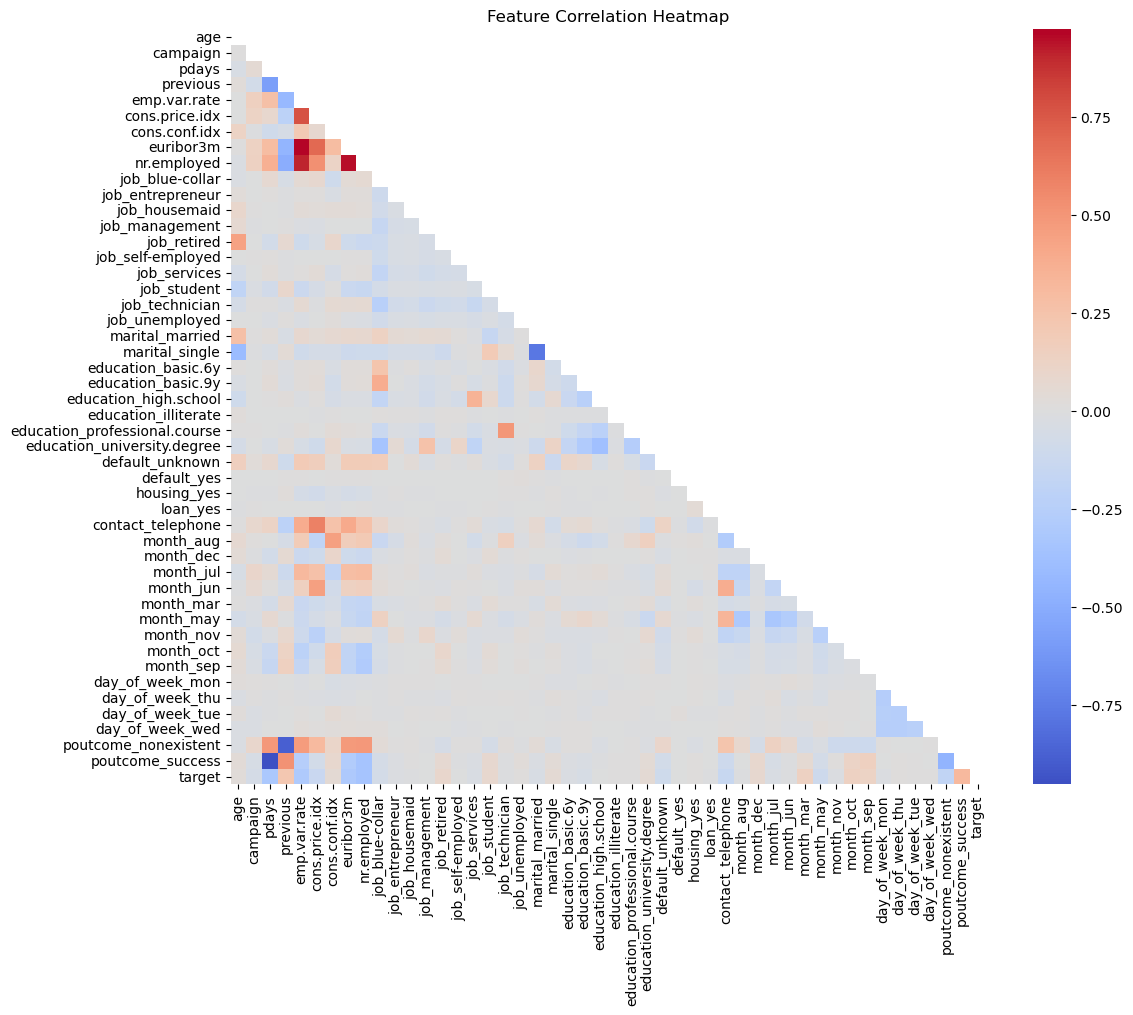

In [19]:
X_transformed = column_preprocessor.fit_transform(X)

feature_names = (
    num_cols + 
    column_preprocessor.named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(cat_cols).tolist()
)

X_transformed_df = pd.DataFrame(
    X_transformed.toarray() if hasattr(X_transformed, 'toarray') else X_transformed,
    columns=feature_names
)

X_transformed_df['target'] = y.values

plt.figure(figsize=(12, 10))
correlation_matrix = X_transformed_df.corr()
target_corr = correlation_matrix['target'].drop('target')
target_corr_abs = target_corr.abs().sort_values(ascending=False)

mask = np.triu(np.ones_like(correlation_matrix))

# Focus on correlation with target
print("Top correlations with Target")
print(pd.DataFrame({
    'Feature': target_corr_abs.index,
    'Correlation': target_corr[target_corr_abs.index].values,
    'Abs_Correlation': target_corr_abs.values
}).sort_values('Abs_Correlation', ascending=False).head(20))

sns.heatmap(correlation_matrix, cmap='coolwarm', mask=mask, center=0, 
            annot=False, fmt='.2f', square=True)
plt.title('Feature Correlation Heatmap')
plt.savefig('images/feature_correlation_heatmap.png')
plt.tight_layout()
plt.show()

In [22]:
feature_corr = correlation_matrix.drop('target', axis=0).drop('target', axis=1)

threshold = 0.8  # threshold for multicollinearity
high_corr_pairs = []

for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        if abs(feature_corr.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Feature_1': feature_corr.columns[i],
                'Feature_2': feature_corr.columns[j],
                'Correlation': feature_corr.iloc[i, j],
                'Abs_Correlation': abs(feature_corr.iloc[i, j])
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Abs_Correlation', ascending=False)
print(f"\nFound {len(high_corr_df)} feature pairs with |correlation| > {threshold}:")
print(high_corr_df.to_string(index=False))


Found 5 feature pairs with |correlation| > 0.8:
   Feature_1            Feature_2  Correlation  Abs_Correlation
emp.var.rate            euribor3m     0.972422         0.972422
       pdays     poutcome_success    -0.952692         0.952692
   euribor3m          nr.employed     0.945336         0.945336
emp.var.rate          nr.employed     0.907920         0.907920
    previous poutcome_nonexistent    -0.881791         0.881791


### Observations

With the above highly correlated features, consider nixing:
- emp.var.rate, due to its high correlation with euribor3m and nr.employed
- nr.employed,due to its high correlation with euribor3m

9


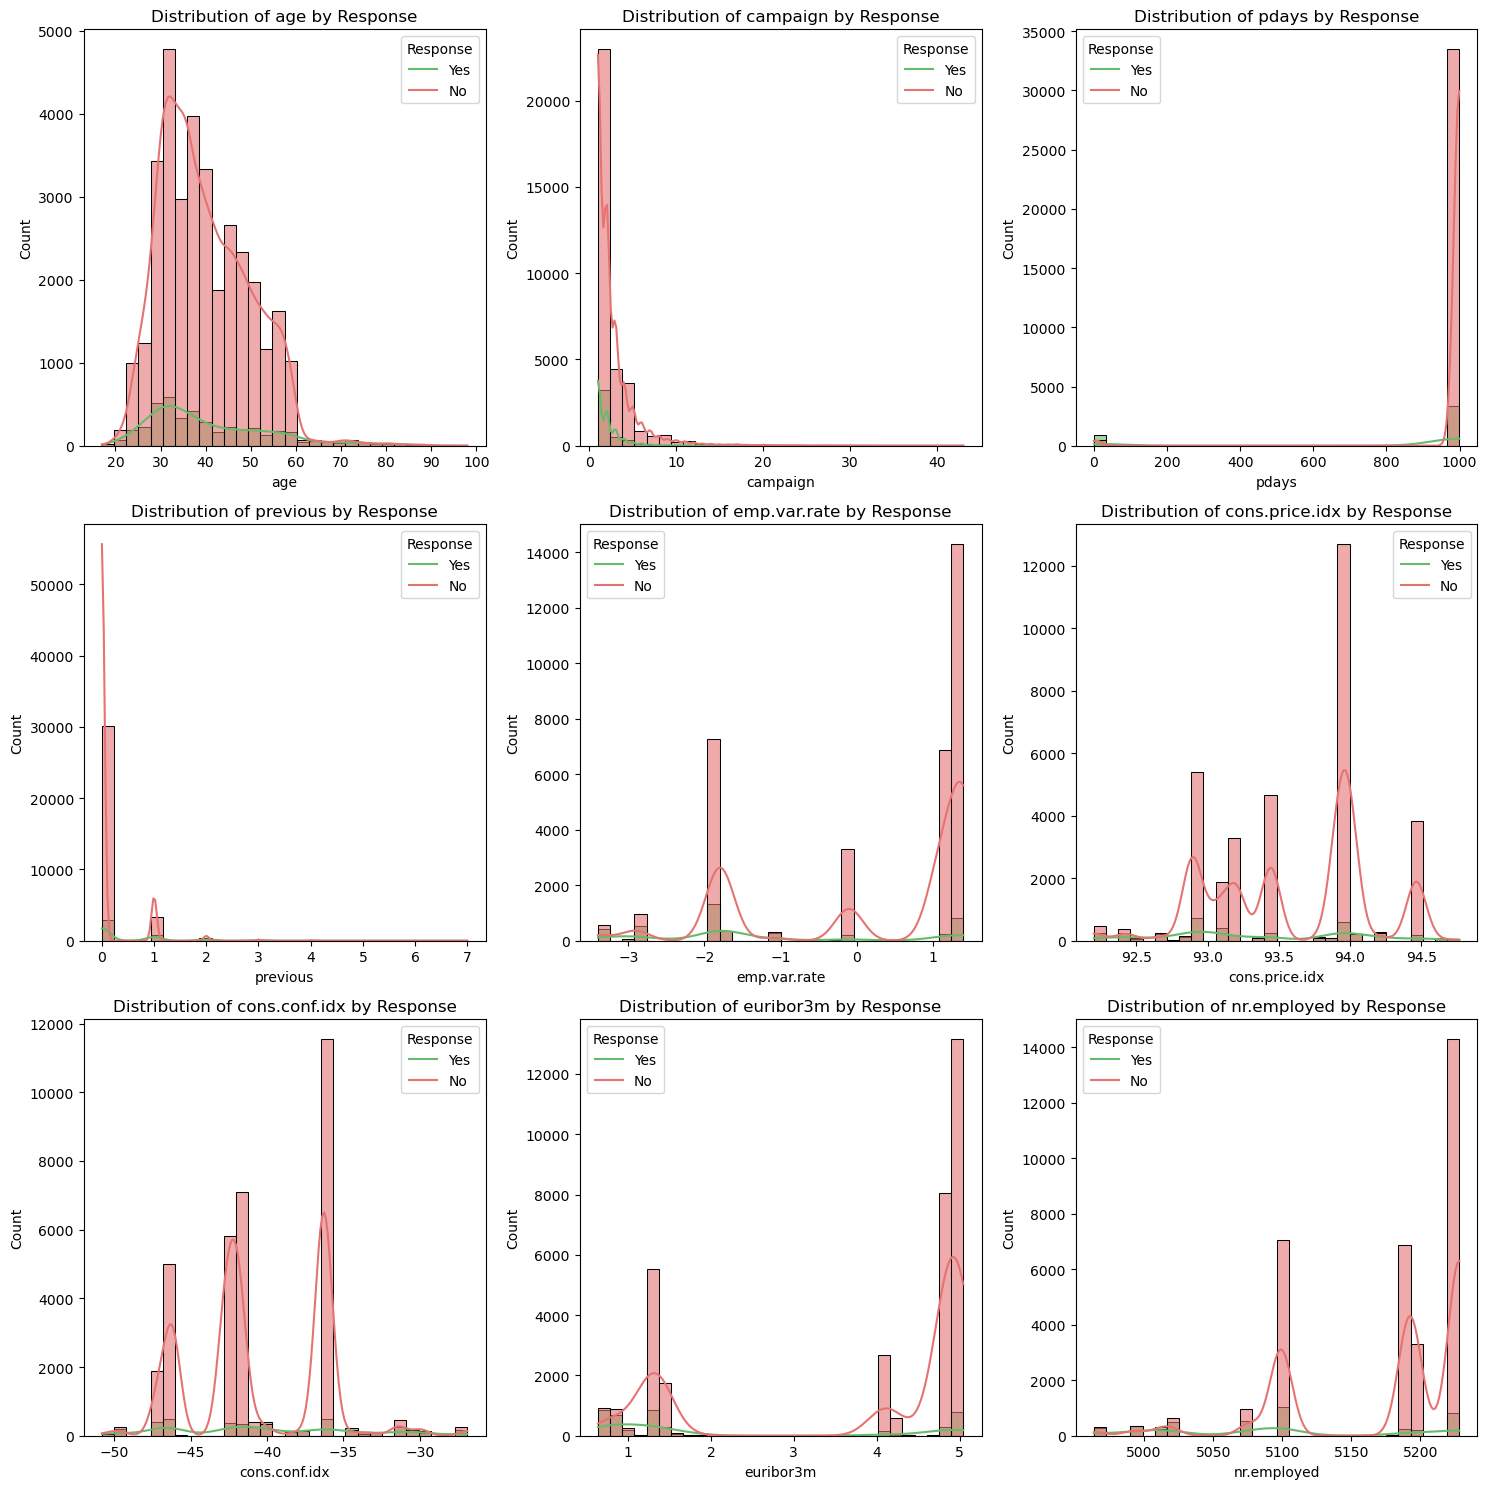

In [20]:
num_to_plot = [c for c in num_cols if bank_data_full[c].nunique() > 5]

# Calculate rows and columns for better layout
n_plots = len(num_to_plot)
n_cols = 3  # 3 plots per row (adjust as needed)
n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division

# Create subplots with proper dimensions
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

print(n_plots)
# Flatten axes array for easy iteration
axes = axes.flatten() if n_plots > 1 else [axes]

# Plot each distribution
for idx, col in enumerate(num_to_plot):
   
    # Plot with hue for yes/no
    sns.histplot(data=bank_data_clean, x=col, hue='y', kde=True, ax=axes[idx], 
                 palette={'no':  '#E57373', 'yes': '#66BB6A'}, 
                 alpha=0.6, bins=30)
    
    axes[idx].set_title(f"Distribution of {col} by Response")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")
    axes[idx].legend(title='Response', labels=['Yes', 'No'])

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('images/numerical-distributions.png')
plt.show()

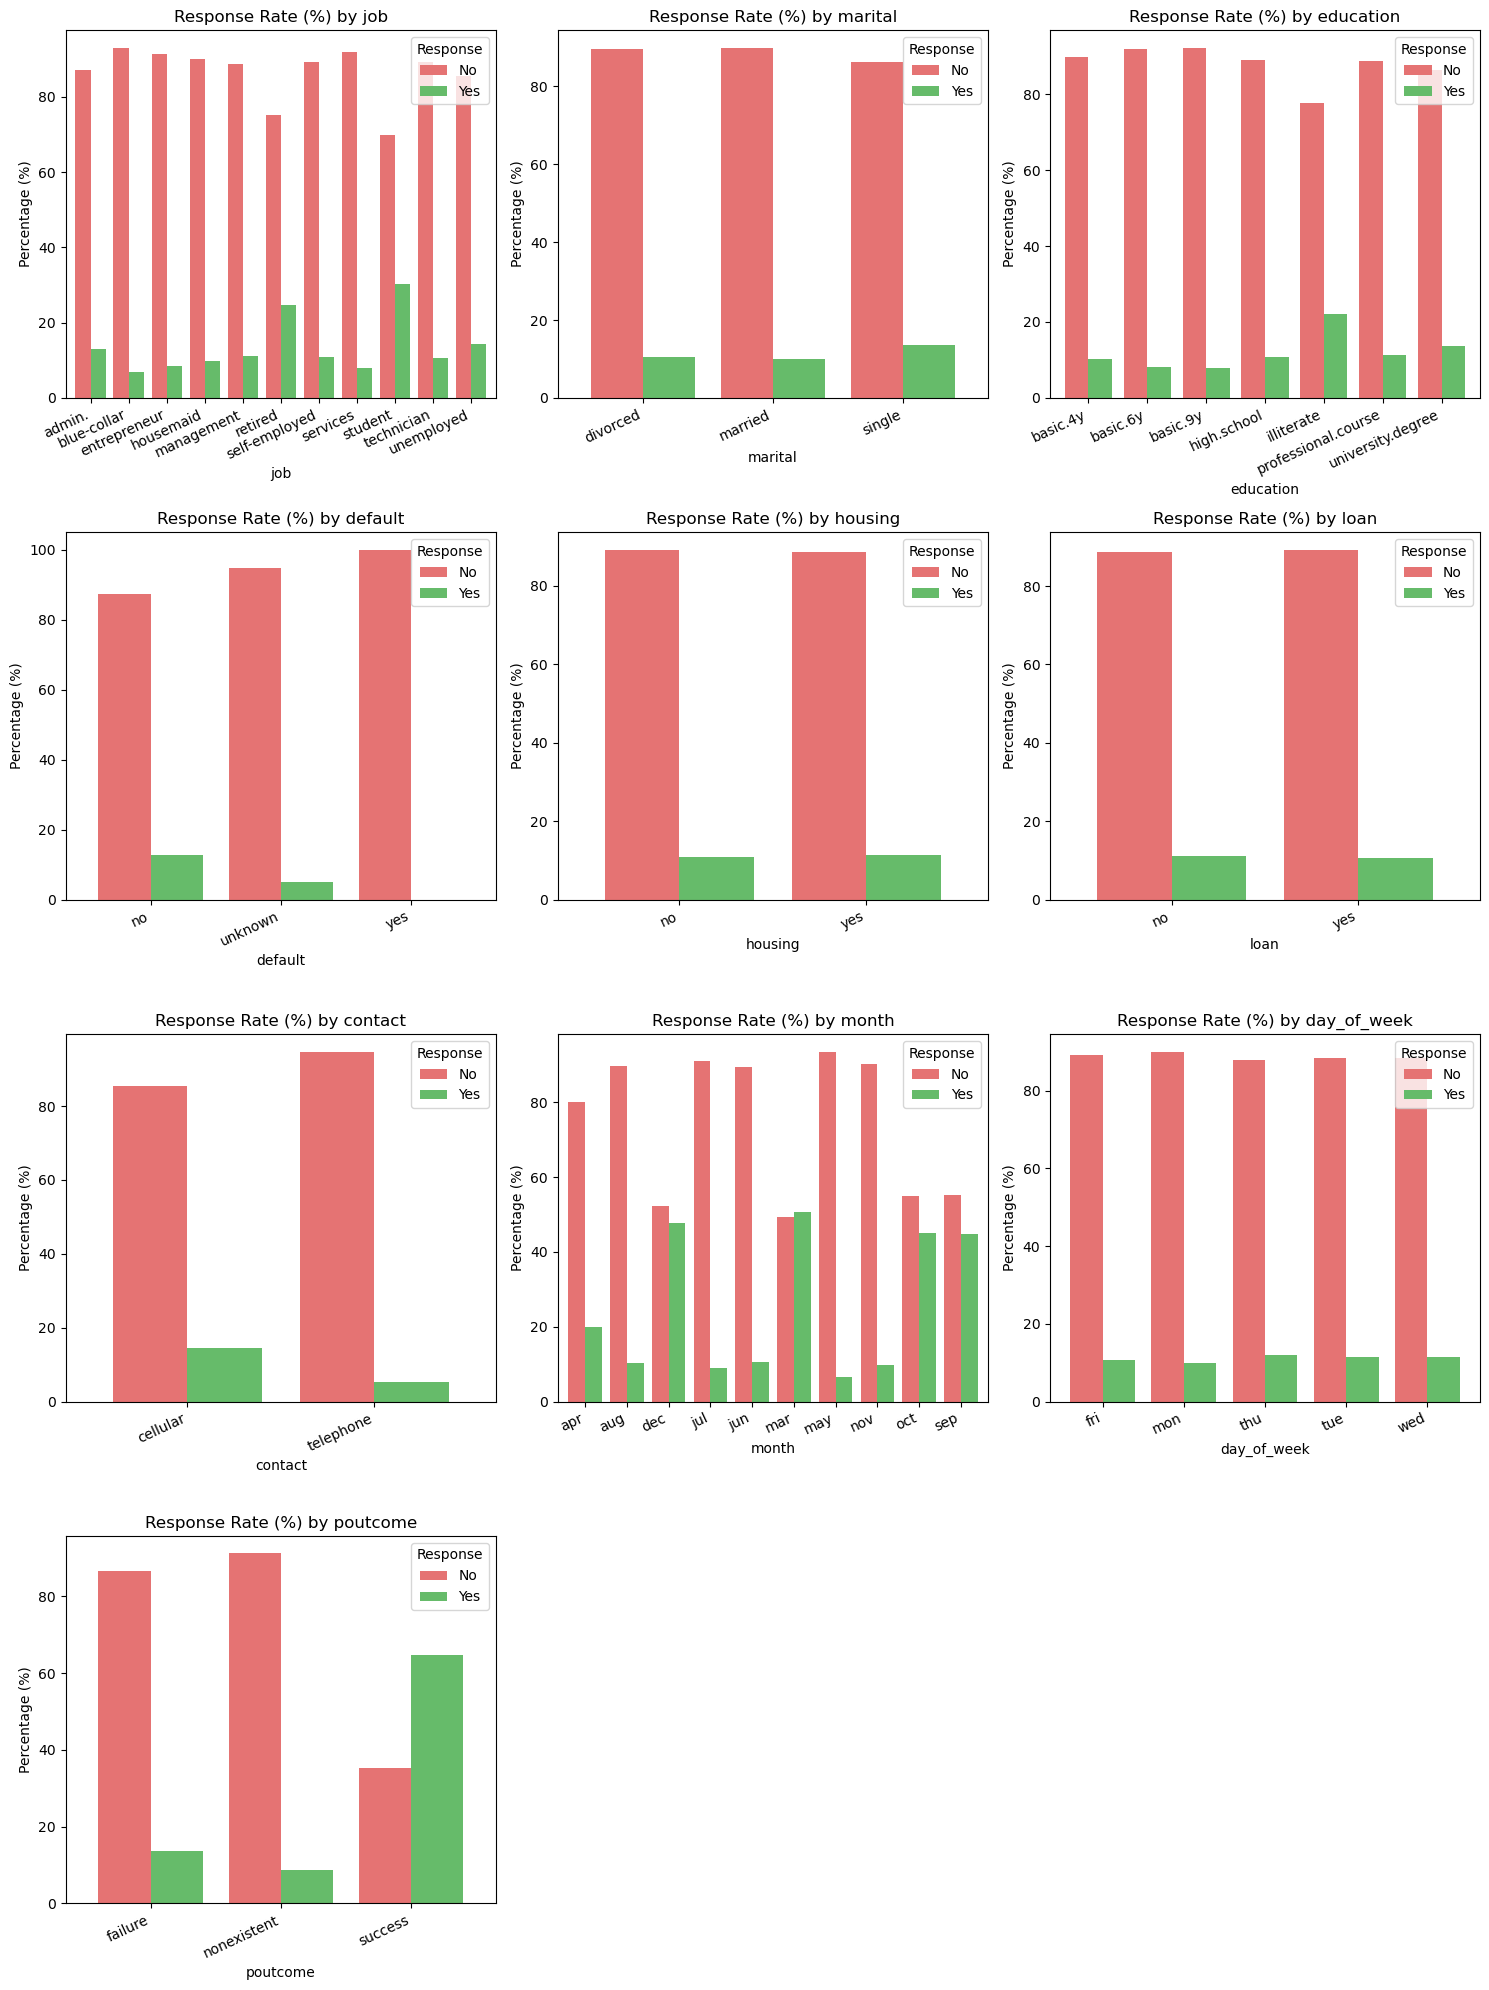

In [ ]:
cat_to_plot = cat_cols[:10]
# Calculate rows and columns for better layout
n_plots = len(cat_to_plot)
n_cols = 3  # 3 plots per row (adjust as needed)
n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division

# Create subplots with proper dimensions
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Flatten axes array for easy iteration
axes = axes.flatten() if n_plots > 1 else [axes]

# Plot each categorical variable
for idx, col in enumerate(cat_to_plot):
    # Create crosstab with percentages
    ct = pd.crosstab(X[col], bank_data_clean['y'], normalize='index') * 100
    
    # Plot on the specific axis
    ct.plot(kind='bar', color=['#E57373', '#66BB6A'], width=0.8, ax=axes[idx])
    
    axes[idx].set_title(f"Response Rate (%) by {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Percentage (%)")
    axes[idx].legend(title='Response', labels=['No', 'Yes'], loc='best')
    axes[idx].tick_params(axis='x', rotation=25)
    
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), ha='right')

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('images/response_rates_by_category.png')
plt.show()

### Observations 

With all categorical columns except default 'unknown' values nixed, we can see that: 
- **`poutcome` success** indicates strong likelihood of subscription, despite 80% of values being 'nonexistent'
- **`pdays` negative correlation** with `poutcome_success` (-0.95) reflects that successful contacts naturally have shorter intervals
- **Economic indicators** (`emp.var.rate`, `euribor3m`, `nr.employed`) are highly correlated (0.90-0.97) → keep only `euribor3m`
- **`month` shows strong seasonality**: Mar/Sep/Oct/Dec (~50% Yes) vs May (~5% Yes)
- **`contact` type matters**: cellular (~15%) outperforms telephone (~5%)
- **Weak predictors to drop**: `default`, `housing`, `loan`, `marital`, `day_of_week` (all ~85-90% No)
- **Moderate predictors to keep**: `job`, `education` (students/retired/high school show ~25-30% response)
- **Previous campaign features** are the strongest predictors overall

In [25]:
features_to_drop = [
  'emp.var.rate',         
  'nr.employed',   
  'default',             
  'housing',               
  'loan',                  
  'marital',               
  'day_of_week', 
]

num_features = [col for col in num_cols if col not in features_to_drop]
cat_features = [col for col in cat_cols if col not in features_to_drop]

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [26]:
X_features = X.drop(columns=features_to_drop)

In [27]:

preprocessor = ColumnTransformer(
  transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
  ],
  remainder='drop'
)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y,
    test_size=0.2,
    random_state=42,
    stratify=y if pd.Series(y).nunique() > 1 else None
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (30596, 12) Test size: (7649, 12)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [29]:
baseline_lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

baseline_lr.fit(X_train, y_train)
baseline_pred = baseline_lr.predict(X_test)
baseline_proba = baseline_lr.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression (test):")
print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, baseline_proba))

Baseline Logistic Regression (test):
Accuracy: 0.9007713426591711
F1: 0.3347940403155127
ROC-AUC: 0.7823488303663381


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [30]:

knn_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=15))
])
start_time = time.time()
knn_pipe.fit(X_train, y_train)

knn_pred = knn_pipe.predict(X_test)
knn_proba = knn_pipe.predict_proba(X_test)[:, 1]

print("KNN (test):")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("F1:", f1_score(y_test, knn_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, knn_proba))

KNN (test):
Accuracy: 0.9006406066152438
F1: 0.3958664546899841
ROC-AUC: 0.7613052154326577


In [31]:
k_used = knn_pipe.named_steps['model'].n_neighbors
print(f"K used in KNN: {k_used}")

K used in KNN: 15


### Problem 9: Score the Model

What is the accuracy of your model?

For response problems

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [57]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'f1_weighted': 'f1_weighted',
    'f1': 'f1',
    'recall_weighted': 'recall_weighted', 
    'roc_auc': 'roc_auc_ovr',
    'precision_weighted': 'precision_weighted', 
    'accuracy': 'accuracy',  
    'precision_recall_auc': 'average_precision'
}

models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
}

cv_rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    start_train_time = time.time()
    out = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    end_train_time = time.time()
    cv_rows.append({
        "model": name,
        "accuracy": out["test_accuracy"].mean(),                    
        "precision": out["test_precision_weighted"].mean(),        
        "recall": out["test_recall_weighted"].mean(),               
        "f1": out["test_f1"].mean(),
        "f1_weighted": out["test_f1_weighted"].mean(),                       
        "roc_auc": out["test_roc_auc"].mean(),                      
        "precision_recall_auc": out["test_precision_recall_auc"].mean(),  
        "Train Time (s)": out['fit_time'].mean(),
        "Test Time (s)": out["score_time"].mean()
    })

holdout_df = pd.DataFrame(cv_rows).sort_values("f1", ascending=False).reset_index(drop=True)
holdout_df

python(36647) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(36648) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(36649) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(36650) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(36651) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(36652) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(36653) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(36654) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,model,accuracy,precision,recall,f1,f1_weighted,roc_auc,precision_recall_auc,Train Time (s),Test Time (s)
0,KNN,0.889920,0.869444,0.889920,0.359483,0.875184,0.730377,0.312540,0.102903,1.679215
1,SVM (RBF),0.901687,0.883842,0.901687,0.359184,0.881349,0.685135,0.383858,201.005533,15.539672
2,Logistic Regression,0.900673,0.882237,0.900673,0.333033,0.878066,0.783425,0.434979,0.088193,0.041210
3,Decision Tree,0.846091,0.847579,0.846091,0.316194,0.846814,0.621468,0.181877,0.239357,0.081140


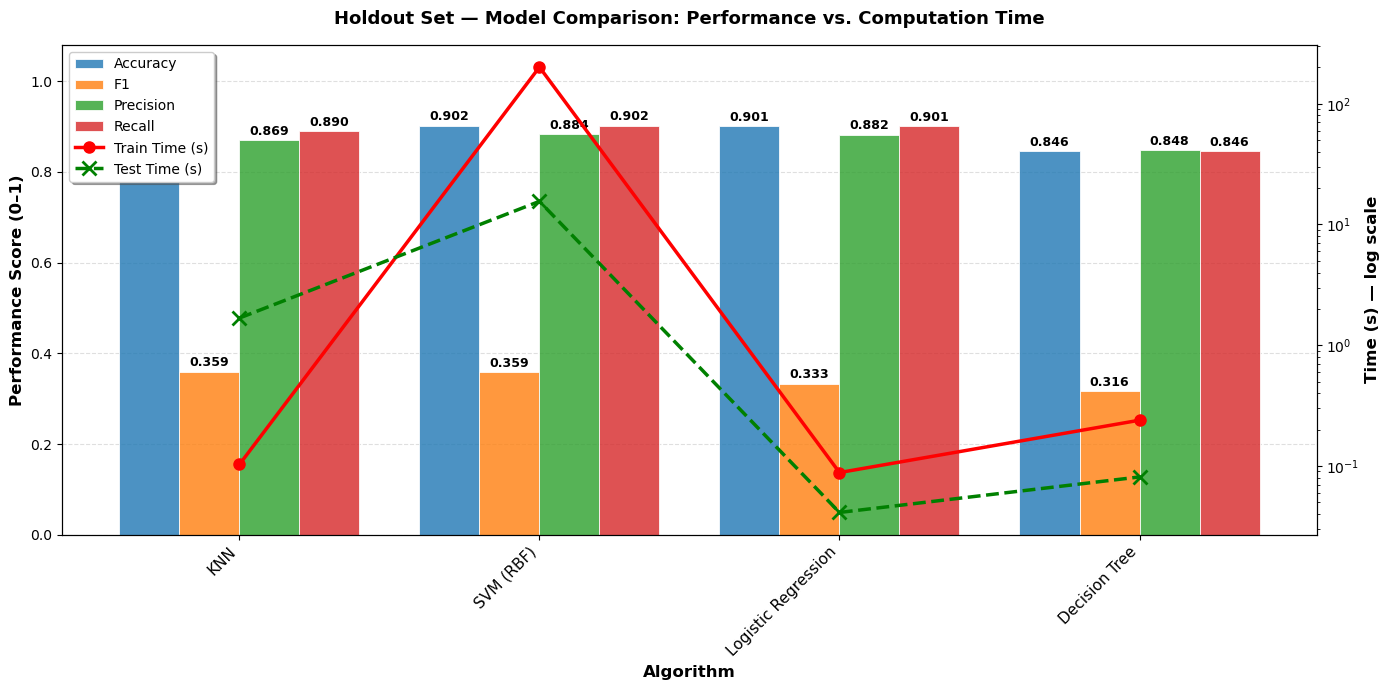

In [91]:
def create_improved_graph(results_df, image_name):
    """
    Create comprehensive model comparison graph with performance metrics and timing
    
    Parameters:
    - results_df: DataFrame with columns ['model', 'accuracy', 'f1', 'precision', 'recall', 'Train Time (s)', 'Test Time (s)']
    - image_name: Name for saved image file
    - figsize: Figure size tuple
    """
    
    fig, ax = plt.subplots(figsize=(14,7))

    algorithms = results_df['model']
    x_pos = np.arange(len(algorithms))
    width = 0.2  # Adjusted for 4 metrics

    metric_names = ['accuracy', 'f1', 'precision', 'recall']

    for i, metric in enumerate(metric_names):
        values = results_df[metric].values  
        bars = ax.bar(x_pos + i * width, values, width, label=metric.capitalize(), 
                     color=f'C{i}', alpha=0.8, edgecolor='white', linewidth=0.7)
        
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{value:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax2 = ax.twinx()
    ax2.set_yscale('log')

    ax2.plot(x_pos + width*1.5, results_df['Train Time (s)'], 'ro-',  # Centered on bars
             label='Train Time (s)', linewidth=2.5, markersize=8)
    ax2.plot(x_pos + width*1.5, results_df['Test Time (s)'],  'gx--',  # Centered on bars
             label='Test Time (s)',  linewidth=2.5, markersize=10, markeredgewidth=2)

    ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
    ax.set_ylabel('Performance Score (0–1)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Time (s) — log scale', fontsize=12, fontweight='bold')

    ax.set_xticks(x_pos + width*1.5)  # Center x-ticks on the grouped bars
    ax.set_xticklabels(algorithms, fontsize=11, rotation=45, ha='right')
    ax.set_ylim(0, 1.08)
    ax.set_title('Holdout Set — Model Comparison: Performance vs. Computation Time',
                  fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')
    ax.set_axisbelow(True)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10, 
              frameon=True, fancybox=True, shadow=True)  
    
    plt.savefig(f'images/{image_name}_model_comparison.png')

    plt.tight_layout()

create_improved_graph(holdout_df, 'holdout_set')

### Cross-validation comparison plot

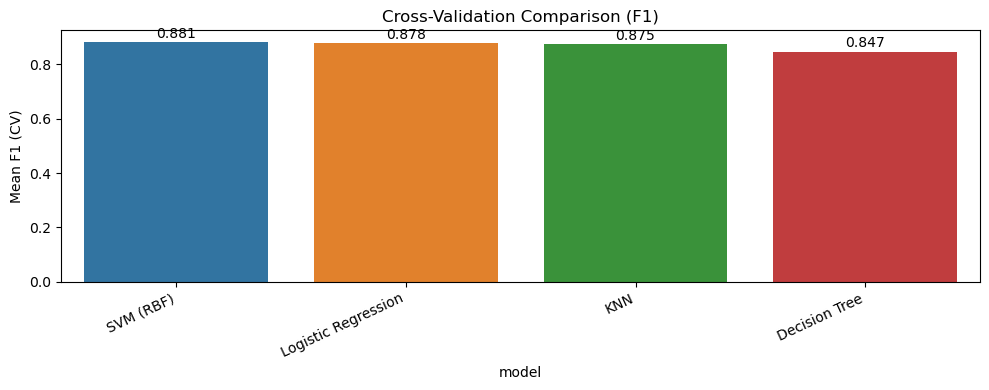

In [34]:
plt.figure(figsize=(10, 4))

ax = sns.barplot(data=holdout_df, x='model', y='f1', hue='model')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=10
    )
plt.title("Cross-Validation Comparison (F1)")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean F1 (CV)")
plt.tight_layout()
plt.savefig("images/cv_f1_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  Due to the class imbalance in the dataset, we consider class weights for models. 
- Adjust your performance metric

In [62]:
random_param_grids = {
    'Logistic Regression': {
        'model__C': [0.1, 1.0, 10.0],  # Only 3 values
        'model__class_weight': ['balanced'],  
        'model__solver': ['liblinear']  
    },
    
    'Decision Tree': {
        'model__max_depth': [5, 10, 15, 20],  # Shallow to medium depth
        'model__min_samples_split': [10, 20],  # Higher values for large dataset
        'model__class_weight': ['balanced'],  # Handle imbalance
        'model__criterion': ['gini']  # Skip entropy for speed
    },
    
    'SVM (RBF)': {
        'model__C': [.5, 1.0, 5.0, 10.0],  
        'model__gamma': ['scale', 0.1],  
        'model__class_weight': ['balanced']  
    },
    
    'KNN': {
        'model__n_neighbors': [9, 11, 13],  
        'model__weights': ['distance']  
    }
}

best_models = {}
tuning_rows = []

for name, model in models.items():
    print(f"Performing randomized search for {name}...")
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    start_time = time.time()
    search = RandomizedSearchCV(
        pipe,
        random_param_grids[name],
        n_iter=6,  # small number of iterations
        cv=3,      # Only 3-fold CV
        scoring='f1_weighted',  # Good for imbalanced data
        n_jobs=-1,
        random_state=42
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    tuning_rows.append({
        "model": f"Tuned {name}", 
        "best_f1_cv": search.best_score_, 
        "best_params": search.best_params_,
        "Train Time(s)": search.cv_results_['mean_fit_time'].mean(),
        "Test Time(s)": search.cv_results_['mean_score_time'].mean()
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("best_f1_cv", ascending=False).reset_index(drop=True)
tuning_df

Performing randomized search for KNN...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=6. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
python(18554) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18555) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18556) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18557) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18558) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18559) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18560) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18561) MallocStackLogging: can't turn off malloc stack logging because

Performing randomized search for Logistic Regression...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=6. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Performing randomized search for Decision Tree...
Performing randomized search for SVM (RBF)...


,model,best_f1_cv,best_params,Train Time(s),Test Time(s)
0,Tuned KNN,0.871183,"{'model__weights': 'distance', 'model__n_neigh...",0.129886,1.377190
1,Tuned Decision Tree,0.858782,"{'model__min_samples_split': 20, 'model__max_d...",0.144863,0.028297
2,Tuned SVM (RBF),0.853704,"{'model__gamma': 'scale', 'model__class_weight...",334.214022,21.004712
3,Tuned Logistic Regression,0.841545,"{'model__solver': 'liblinear', 'model__class_w...",0.165366,0.030326


In [61]:
for _, row in tuning_df.iterrows():
    print(f"\n{'='*50}")
    print(f"Model: {row['model']}")
    print(f"Model fit time: {row['Train Time(s)']:.4f} seconds")
    print(f"Best F1 CV: {row['best_f1_cv']:.4f}")
    print(f"Best Params:")
    for param, value in row['best_params'].items():
        print(f"  {param}: {value}")


Model: Tuned KNN
Model fit time: 11.1927 seconds
Best F1 CV: 0.8712
Best Params:
  model__weights: distance
  model__n_neighbors: 13

Model: Tuned Decision Tree
Model fit time: 0.8743 seconds
Best F1 CV: 0.8588
Best Params:
  model__min_samples_split: 20
  model__max_depth: 5
  model__criterion: gini
  model__class_weight: balanced

Model: Tuned SVM (RBF)
Model fit time: 1116.6922 seconds
Best F1 CV: 0.8537
Best Params:
  model__gamma: scale
  model__class_weight: balanced
  model__C: 0.5

Model: Tuned Logistic Regression
Model fit time: 0.5839 seconds
Best F1 CV: 0.8415
Best Params:
  model__solver: liblinear
  model__class_weight: balanced
  model__C: 10.0


In [63]:
k_best = best_models['KNN'].named_steps['model'].n_neighbors
print("K (best n_neighbors):", k_best)

K (best n_neighbors): 13


### Tuned Decision Tree Metrics

1. Compute Predictions
2. Compute Metrics
3. Create dictionary

In [64]:

# ---- Tuned Decision Tree: compute metrics first, then build the summary row ----
tuned_dt = best_models.get("Decision Tree")
if tuned_dt is None:
    raise ValueError("Tuned Decision Tree not found. Make sure GridSearchCV ran and best_models was created.")

# Predict on the test set
dt_pred = tuned_dt.predict(X_test)
dt_proba = tuned_dt.predict_proba(X_test)[:, 1]

# Compute metrics (these variables now exist)
accuracy_dt = accuracy_score(y_test, dt_pred)
precision_dt = precision_score(y_test, dt_pred, zero_division=0)
recall_dt = recall_score(y_test, dt_pred, zero_division=0)
f1_dt = f1_score(y_test, dt_pred, zero_division=0, average='weighted')
roc_auc_dt = roc_auc_score(y_test, dt_proba)

# Create a row for the tuned Decision Tree's performance
tuned_dt_metrics = {
    "model": "Tuned Decision Tree",
    "accuracy": accuracy_dt,
    "precision": precision_dt,
    "recall": recall_dt,
    "f1": f1_dt,
    "roc_auc": roc_auc_dt
}
tuned_dt_df = pd.DataFrame([tuned_dt_metrics])

# Combine with the previously evaluated models (excluding the untuned Decision Tree row)
comparison_df = pd.concat(
    [holdout_df[holdout_df["model"] != "Decision Tree"], tuned_dt_df],
    ignore_index=True
)

# Sort by F1-score for easy comparison
comparison_df = comparison_df.sort_values(by="f1", ascending=False).reset_index(drop=True)
display(comparison_df)

print("\n--- Comparison Summary ---\n")
print(f"The Tuned Decision Tree achieved an F1-score of {f1_dt:.4f} and ROC-AUC of {roc_auc_dt:.4f}.")

if (holdout_df["model"] == "Decision Tree").any():
    old_f1 = holdout_df.loc[holdout_df["model"] == "Decision Tree", "f1"].iloc[0]
    print(f"Compared to the untuned Decision Tree (CV F1: {old_f1:.4f}), the tuned version shows a change in performance.")

,model,accuracy,precision,recall,f1,f1_weighted,roc_auc,precision_recall_auc,Train Time (s),Test Time (s)
0,Tuned Decision Tree,0.797882,0.304837,0.636150,0.826077,NaN,0.780087,NaN,NaN,NaN
1,KNN,0.889920,0.869444,0.889920,0.359483,0.875184,0.730377,0.312540,0.102903,1.679215
2,SVM (RBF),0.901687,0.883842,0.901687,0.359184,0.881349,0.685135,0.383858,201.005533,15.539672
3,Logistic Regression,0.900673,0.882237,0.900673,0.333033,0.878066,0.783425,0.434979,0.088193,0.041210



--- Comparison Summary ---

The Tuned Decision Tree achieved an F1-score of 0.8261 and ROC-AUC of 0.7801.
Compared to the untuned Decision Tree (CV F1: 0.3162), the tuned version shows a change in performance.


### Final Evaluation (Best Tuned Model)

Select the tuned model with the best test-set F1, present confusion matrix + ROC curve.

In [89]:
test_rows = []

for name, est in best_models.items():
    pred = est.predict(X_test)
    proba = est.predict_proba(X_test)[:, 1]
    test_rows.append({
        "model": f"Tuned {name}",
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "f1_weighted": f1_score(y_test, pred, average = 'weighted'),
        'f1_macro': f1_score(y_test, pred, average = 'macro'),
        "roc_auc": roc_auc_score(y_test, proba),
        "Test Time (s)": tuning_df.loc[tuning_df['model'] == f'Tuned {name}','Test Time(s)'].values[0],
        "Train Time (s)": tuning_df.loc[tuning_df['model'] == f'Tuned {name}', 'Train Time(s)'].values[0]
    })

test_df = pd.DataFrame(test_rows).sort_values("f1", ascending=False).reset_index(drop=True)
test_df

,model,accuracy,precision,recall,f1,f1_weighted,f1_macro,roc_auc,Test Time (s),Train Time (s)
0,Tuned SVM (RBF),0.837364,0.363128,0.610329,0.455342,0.854390,0.679876,0.770580,21.004712,334.214022
1,Tuned Logistic Regression,0.817623,0.328707,0.611502,0.427575,0.839854,0.659554,0.787151,0.030326,0.165366
2,Tuned Decision Tree,0.797882,0.304837,0.636150,0.412167,0.826077,0.645064,0.780087,0.028297,0.144863
3,Tuned KNN,0.885083,0.476684,0.323944,0.385744,0.875253,0.661178,0.729888,1.377190,0.129886


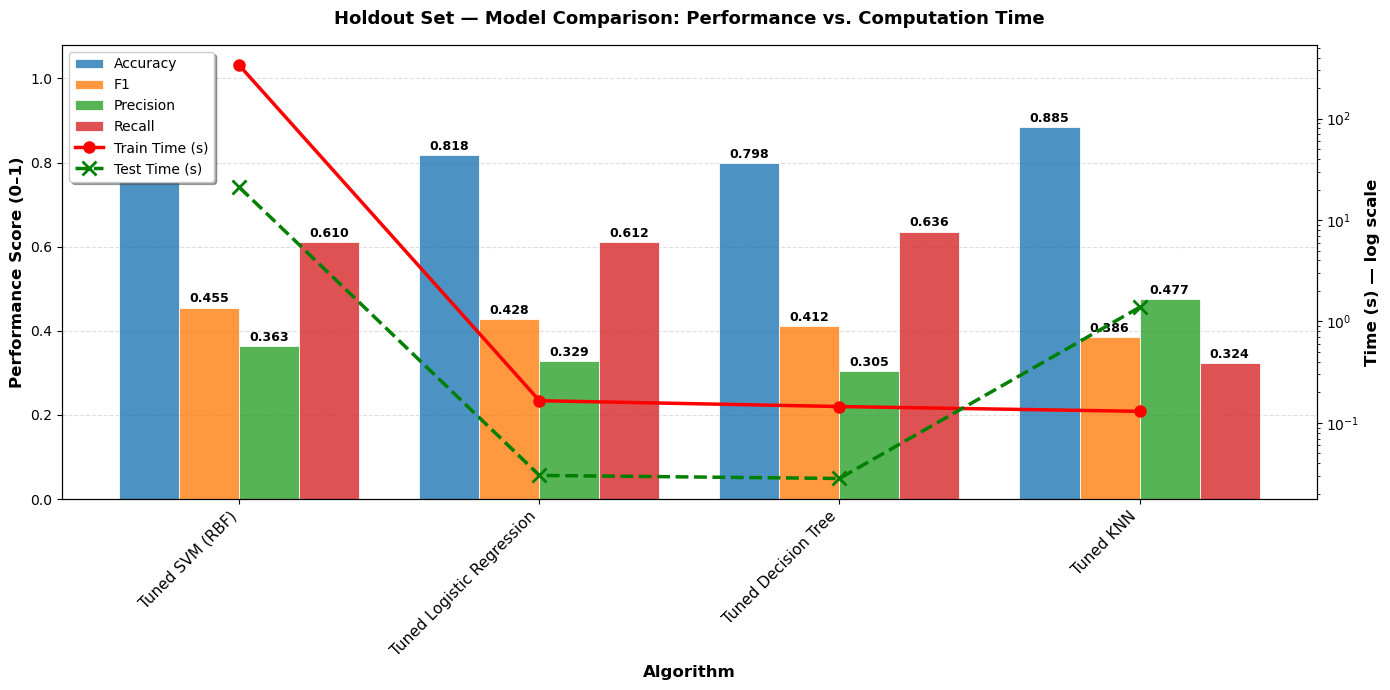

In [92]:
create_improved_graph(test_df, 'final_tuned_models')

Selected final model: Tuned SVM (RBF)


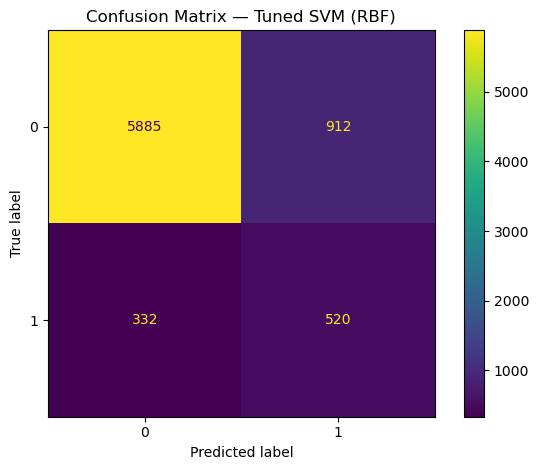

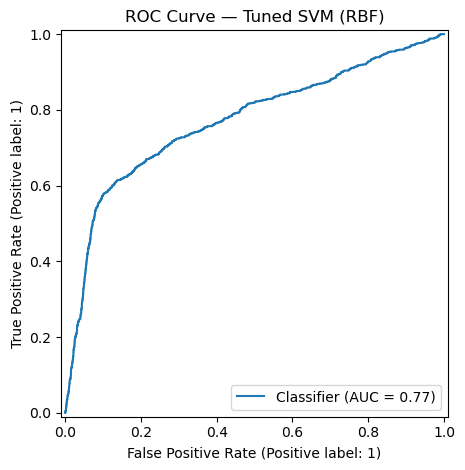

In [ ]:
final_model_name = test_df.loc[0, "model"]
final_base_name = final_model_name.replace("Tuned ", "")
final_model = best_models[final_base_name]

print("Selected final model:", final_model_name)

final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]

ConfusionMatrixDisplay.from_predictions(y_test, final_pred, values_format="d")
plt.title(f"Confusion Matrix — {final_model_name}")
plt.tight_layout()
plt.savefig('images/final_model_confusion_matrix.png')
plt.show()

RocCurveDisplay.from_predictions(y_test, final_proba)
plt.title(f"ROC Curve — {final_model_name}")
plt.tight_layout()
plt.savefig('images/final_model_roc_auc_curve.png')
plt.show()

In [ ]:
# Helper: get feature names after preprocessing
def get_feature_names(pipeline):
    preprocessor = pipeline.named_steps['preprocess']
    try:
        return preprocessor.get_feature_names_out()
    except AttributeError:
        return X_train.columns.tolist()

# ── 1. Logistic Regression ──────────────────────────────────────────
log_reg_pipeline = best_models['Logistic Regression']  # adjust key name as needed
log_reg_model = log_reg_pipeline.named_steps['model']

feature_names = get_feature_names(log_reg_pipeline)

# For binary: coef_ shape is (1, n_features); for multiclass: (n_classes, n_features)
if log_reg_model.coef_.shape[0] == 1:
    coef_values = log_reg_model.coef_[0]
else:
    # Average absolute coefficients across classes for multiclass
    coef_values = np.mean(np.abs(log_reg_model.coef_), axis=0)

coef_logistic_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef_values
}).sort_values(by='coefficient', ascending=False)

print("\nCoefficients from Logistic Regression:")


# ── 2. Decision Tree ────────────────────────────────────────────────
tree_pipeline = best_models['Decision Tree']  # adjust key name as needed
tree_model = tree_pipeline.named_steps['model']

feature_names = get_feature_names(tree_pipeline)

feature_importance_tree_df = pd.DataFrame({
    'feature': feature_names,
    'importance': tree_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importance from Decision Tree:")


# ── 3. KNN (Permutation Importance) ─────────────────────────────────
knn_pipeline = best_models['KNN']

result_knn = permutation_importance(
    knn_pipeline, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring='f1_weighted'
)

perm_importances_knn = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result_knn.importances_mean
}).sort_values(by='importance', ascending=False)

print("\nPermutation Importance from KNN:")


# ── 4. SVM (Permutation Importance) ─────────────────────────────────
svm_pipeline = best_models['SVM (RBF)']  # adjust key name as needed

result_svm = permutation_importance(
    svm_pipeline, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring='f1_weighted'
)

perm_importances_svm = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result_svm.importances_mean
}).sort_values(by='importance', ascending=False)

print("\nPermutation Importance from SVM:")


Coefficients from Logistic Regression:
                               feature  coefficient
28                      cat__month_mar     1.282513
20           cat__education_illiterate     0.890605
34               cat__poutcome_success     0.781523
31                      cat__month_oct     0.651352
33           cat__poutcome_nonexistent     0.443363
11                    cat__job_retired     0.347956
14                    cat__job_student     0.312972
4                  num__cons.price.idx     0.281593
25                      cat__month_dec     0.276671
5                   num__cons.conf.idx     0.253367
26                      cat__month_jul     0.204130
22    cat__education_university.degree     0.174597
17             cat__education_basic.6y     0.166068
21  cat__education_professional.course     0.092566
19          cat__education_high.school     0.092307
27                      cat__month_jun     0.042781
12              cat__job_self-employed     0.035652
18             cat__educ

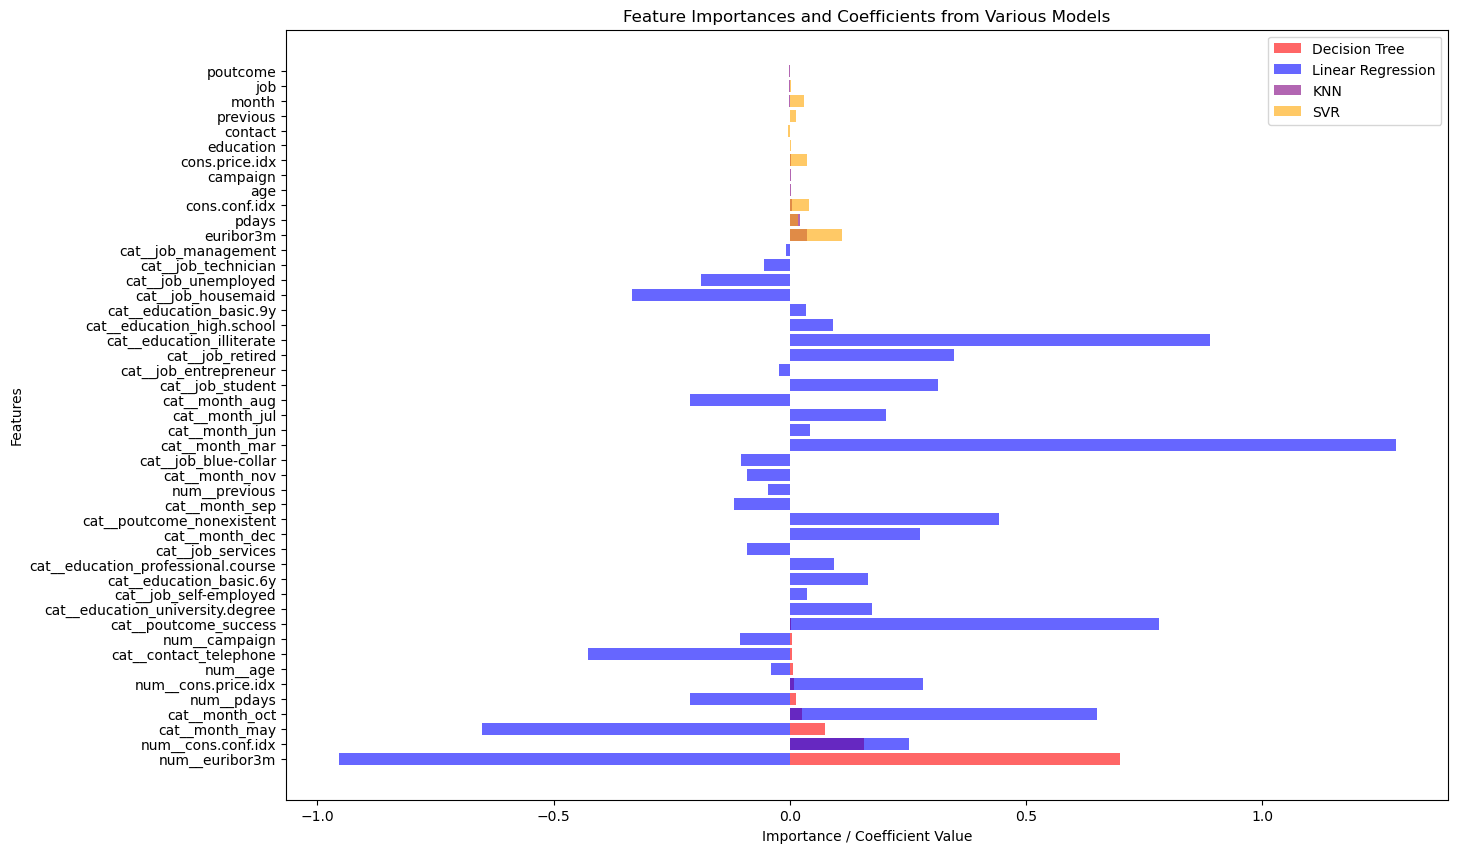

In [85]:
# Plotting the feature importances and coefficients
plt.figure(figsize=(15, 10))

# Plot Decision Tree feature importance
plt.barh(feature_importance_tree_df['feature'], feature_importance_tree_df['importance'], color='red', alpha=0.6, label='Decision Tree')

# Plot Linear Regression coefficients
plt.barh(coef_logistic_df['feature'], coef_logistic_df['coefficient'], color='blue', alpha=0.6, label='Linear Regression')

# Plot KNN permutation importance
plt.barh(perm_importances_knn['feature'], perm_importances_knn['importance'], color='purple', alpha=0.6, label='KNN')

# Plot SVR permutation importance
plt.barh(perm_importances_svm['feature'], perm_importances_svm['importance'], color='orange', alpha=0.6, label='SVR')

plt.xlabel('Importance / Coefficient Value')
plt.ylabel('Features')
plt.title('Feature Importances and Coefficients from Various Models')
plt.savefig('images/feature_importance_and_coefficients.png')
plt.legend()
plt.show()

### Findings and Recommendations

This analysis compared 4 classification models to identify the best approach for predicting which clients are most likely to subscribe to a term deposit. Each model offers different strengths, and the most appropriate choice depends on the specific business goals and scope.

### Key Findings

## Model Performance Overview


1. SVM (RBF) offers the best balanced scores:

- 61% recall indicates reach of most potential customers
- 36% precision is reasonable for marketing (>1/3 contact conversions)
- However, close to 6 minutes for training time and 21 seconds for test time may be suboptimal

2. Logistic Regression offers best interpretability and fit times:
- 61% recall, similar to SVM
- 33% precision (1/3 success rate)
- Highest ROC-AUC (0.787) indicates best probability calibration
- .17 seconds for training time and .03 seconds for test time, vastly superior to SVM

3. Decision Tree maximizes customer reach:
- Highest recall at 64% (highest coverage of potential subscribers)
- 30% precision (requires more contacts per conversion)
- .14 seconds for training time, .02 for test time, slightly faster than Logistic Regression

4. KNN provides the most efficient targeting:
- 48% precision (nearly 1/2 contacts convert)
- Best weighted F1 score at .87
- However, 32% recall leads to missing 68^ of potential customers

## Model Recommendations
- For balanced campaigns, use SVM (RBF), which possesses the best F1 score at 0.455
- For explainable decisions, use Logistic Regression, which provides feature coefficients and probability score 
- For maximum market penetration, use Decision Tree, which captures most potential customers
- For limited budget/high-cost contacts, use K Nearest Neighbors - highest precision minimizes wasted contacts.

## Feature Recommendations
| **Feature** | **Direction** | **Interpretation** |
|---|---|---|
| `euribor3m` | ➕ Strong Positive | Higher Euribor 3-month rate correlates with increased subscription |
| `cons.conf.idx` | ➕ Positive | Higher consumer confidence index boosts subscription likelihood |
| `month == mar` | ➕ Strong Positive | Contacts made in **March** are highly predictive of subscription |
| `education == illiterate` | ➕ Positive | Notable positive signal — may reflect a specific demographic segment |
| `poutcome == succsess` | ➕ Positive | Previous campaign **success** is a strong positive predictor |
| `education == university.degree` | ➕ Positive | University-educated clients are more likely to subscribe |

While euribor3m (daily indicator) and `cons.conf.idx` (monthly indicator) are external and not actionable by the campaign team directly, they are critical for **timing campaign launches** during favorable economic conditions.

##### Questions